# Exploration: ECB Rate Shock and SME Failures

## Objective
First look at the three datasets in hand: ECB policy rates, PME business failures by NAF sector, and FIBEN sector debt structure. Goal: confirm coverage, profile the series, and settle two design points before cleaning, the sector nomenclature match between failures and debt, and the treatment/control split by bank-credit dependence.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

sys.path.insert(0, str(Path().resolve().parent))
from src.data_loader import load_failures, load_sector_debt_structure, load_ecb_rates, SECTOR_LABELS

Path('../outputs').mkdir(exist_ok=True)
ECB_HIKE = pd.Timestamp('2022-07-01')
print('Environment ready')

Environment ready


## 1. ECB policy rates
The first hike of the cycle is the difference-in-differences treatment date.

,main_refi,deposit_facility
observation_date,,
2022-05-01,0.00,-0.50
2022-06-01,0.00,-0.50
2022-07-01,0.50,0.00
2022-08-01,0.50,0.00
2022-09-01,1.25,0.75
2022-10-01,1.25,0.75


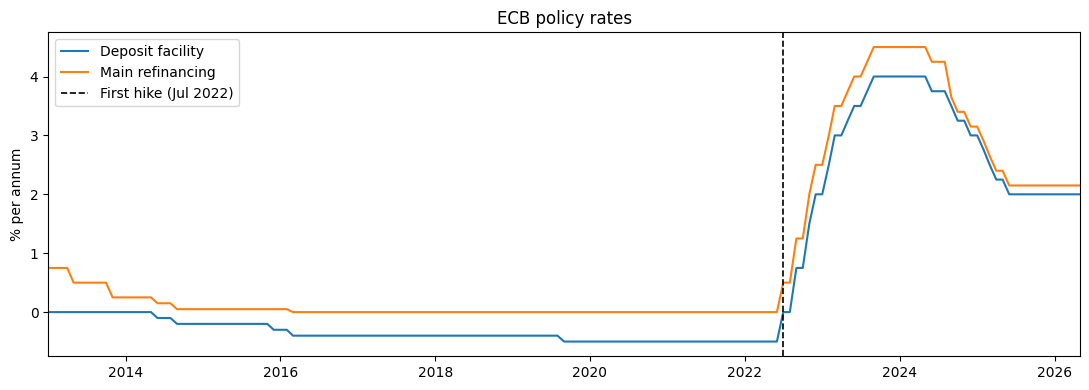

In [2]:
rates = load_ecb_rates()
display(rates.loc['2022-05':'2022-10'])

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(rates.index, rates['deposit_facility'], label='Deposit facility')
ax.plot(rates.index, rates['main_refi'], label='Main refinancing')
ax.axvline(ECB_HIKE, color='black', linestyle='--', linewidth=1.2, label='First hike (Jul 2022)')
ax.set_xlim(pd.Timestamp('2013-01-01'), rates.index.max())
ax.set_ylabel('% per annum')
ax.set_title('ECB policy rates')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/ecb_rates.png', dpi=150, bbox_inches='tight')
plt.show()

**Observations on ECB rates:** flat (or negative deposit rate) through 2014–2021, then a sharp tightening from July 2022. The deposit facility goes from -0.50% to 0.00% in July 2022 and the main refinancing rate from 0.00% to 0.50%, the first move of the cycle. This is the treatment date used throughout the study.

## 2. PME failures by sector (France)
12-month rolling cumulative count of *redressements* and *liquidations judiciaires* for SMEs, by NAF section.

shape: (2736, 4)
sectors: ['AZ', 'BE', 'FZ', 'G', 'H', 'I', 'JZ', 'MN', 'PS']
range: 2000-12-01 -> 2026-03-01


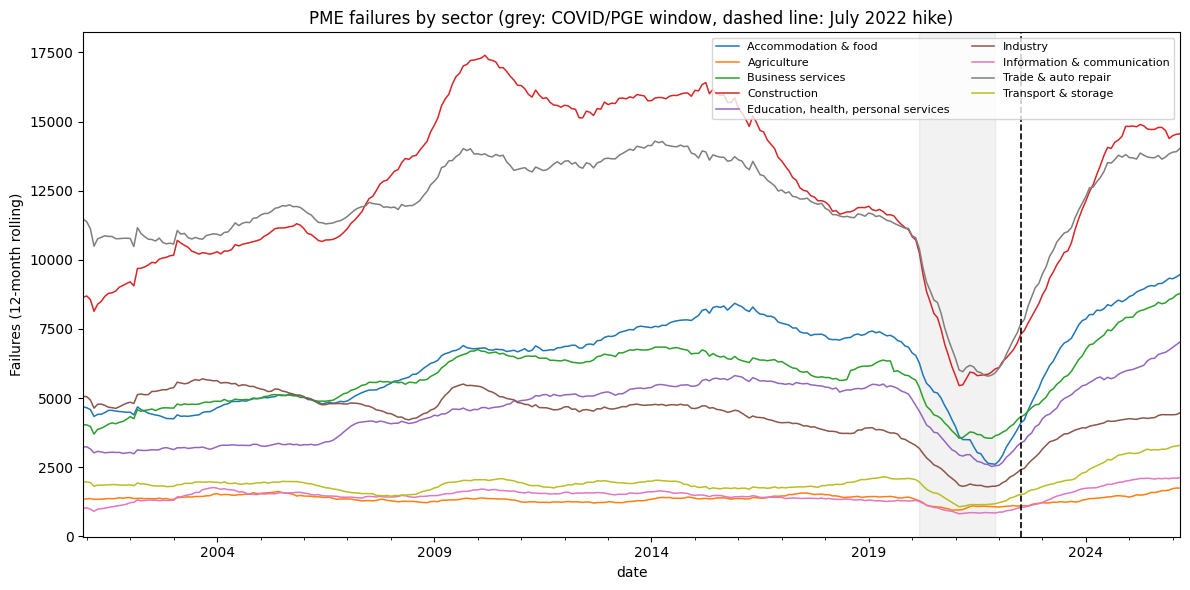

In [3]:
fail = load_failures()
print('shape:', fail.shape)
print('sectors:', sorted(fail['sector'].unique()))
print('range:', fail['date'].min().date(), '->', fail['date'].max().date())

wide = fail.pivot(index='date', columns='sector_label', values='failures')
fig, ax = plt.subplots(figsize=(12, 6))
wide.plot(ax=ax, linewidth=1.1)
ax.axvline(ECB_HIKE, color='black', linestyle='--', linewidth=1.2)
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-31'), alpha=0.10, color='gray')
ax.set_ylabel('Failures (12-month rolling)')
ax.set_title('PME failures by sector (grey: COVID/PGE window, dashed line: July 2022 hike)')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig('../outputs/failures_by_sector.png', dpi=150, bbox_inches='tight')
plt.show()

**Observations on failures:**
- 9 NAF sections available for PME at national level (AZ, BE, FZ, G, H, I, JZ, MN, PS), monthly from 2000.
- The COVID/PGE window (2020–2021) shows the artificial collapse in failures, followed by a clear rebound from 2022, exactly the confounder the design must separate from the rate effect.
- The measure is a 12-month rolling cumulative, so the July 2022 break materialises gradually over the following year.
- Only 9 sectors: this is a small-N panel, which limits statistical power (a point for the Limitations).

## 3. Bank-credit dependence by sector (FIBEN)
Treatment is defined by the share of bank debt in total financial debt (ratio BE), averaged over 2018–2021.

Bank credit is the channel that reprices when policy rates move. A maturity split (short vs long term) would be the ideal exposure measure but it is not published by sector, so the bank-debt share is the closest available proxy.

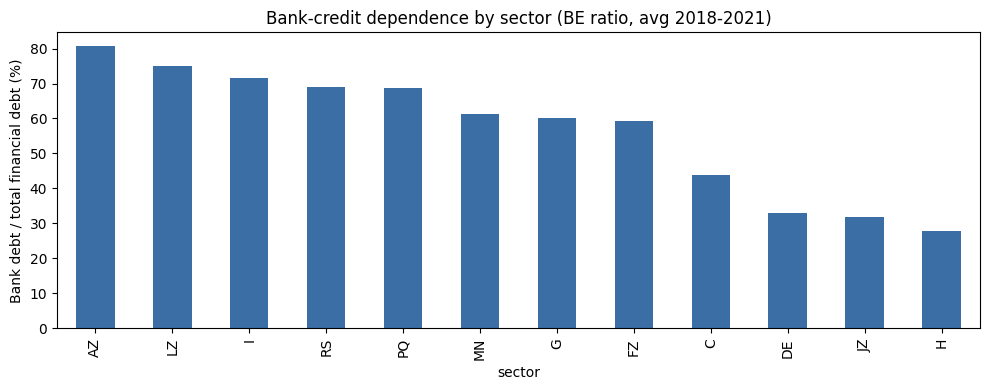

,BE_2018_2021
sector,
AZ,80.6
LZ,75.1
I,71.7
RS,69.1
PQ,68.6
MN,61.3
G,60.0
FZ,59.4
C,43.9


In [4]:
debt = load_sector_debt_structure()
be = debt[(debt['ratio_code'] == 'BE') & (debt['year'].between(2018, 2021))]
be_avg = be.groupby('sector')['value'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
be_avg.plot.bar(ax=ax, color='#3b6ea5')
ax.set_ylabel('Bank debt / total financial debt (%)')
ax.set_title('Bank-credit dependence by sector (BE ratio, avg 2018-2021)')
plt.tight_layout()
plt.savefig('../outputs/bank_debt_share.png', dpi=150, bbox_inches='tight')
plt.show()

display(be_avg.round(1).to_frame('BE_2018_2021'))

## 4. Matching sectors and building the treatment split
The two datasets use slightly different NAF aggregations. Seven sectors match directly. Industry and personal services need aggregating the debt ratio across two sub-sectors (a simple mean here, to be revisited with debt weights, flagged as an approximation).

In [5]:
# failures sector -> debt sub-sectors that compose it
mapping = {
    'AZ': ['AZ'], 'BE': ['C', 'DE'], 'FZ': ['FZ'], 'G': ['G'], 'H': ['H'],
    'I': ['I'], 'JZ': ['JZ'], 'MN': ['MN'], 'PS': ['PQ', 'RS'],
}
rows = []
for sec, parts in mapping.items():
    dep = be_avg.reindex(parts).mean()
    rows.append({'sector': sec, 'label': SECTOR_LABELS[sec],
                 'debt_parts': '+'.join(parts), 'bank_dependence': round(dep, 1),
                 'approx': len(parts) > 1})
split = pd.DataFrame(rows).sort_values('bank_dependence', ascending=False)
threshold = split['bank_dependence'].median()
split['treated'] = split['bank_dependence'] >= threshold
print(f'Threshold (median): {threshold:.1f}%')
display(split.set_index('sector'))

Threshold (median): 60.0%


,label,debt_parts,bank_dependence,approx,treated
sector,,,,,
AZ,Agriculture,AZ,80.6,False,True
I,Accommodation & food,I,71.7,False,True
PS,"Education, health, personal services",PQ+RS,68.8,True,True
MN,Business services,MN,61.3,False,True
G,Trade & auto repair,G,60.0,False,True
FZ,Construction,FZ,59.4,False,False
BE,Industry,C+DE,38.4,True,False
JZ,Information & communication,JZ,31.7,False,False
H,Transport & storage,H,27.7,False,False


## Design findings

**1. Small-N sectoral panel.** Nine sectors, split treatment vs control around the median bank-dependence. Low statistical power and few clusters, so results will be indicative at best. That is the ceiling of open sectoral data.

**2. No sector x territory cross.** Failures exist either by sector at national level *or* by department for all sectors combined, never both at once. The ZFRR (territorial-fragility) question therefore cannot be a sectoral interaction term. It will be a **separate departmental analysis**: department-level all-firm failures (no PME breakdown exists at that level) against the ZFRR intensity of each department, around the same July 2022 break.

Next: notebook 02 builds the clean panel (baseline 2015-2019, COVID/PGE window excluded) and the treatment assignment. Notebook 03 runs the sectoral difference-in-differences and notebook 04 the territorial one.